In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/davidnagib/tweets-dataset/train.csv
/kaggle/input/datasets/keshav2428cseaiml/bert-base-uncased/tokenizer.json
/kaggle/input/datasets/keshav2428cseaiml/bert-base-uncased/tokenizer_config.json
/kaggle/input/datasets/keshav2428cseaiml/bert-base-uncased/vocab.txt


In [16]:
%%time

import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

CPU times: user 22 µs, sys: 2 µs, total: 24 µs
Wall time: 25.7 µs


In [3]:
%%time

data = pd.read_csv("/kaggle/input/datasets/davidnagib/tweets-dataset/train.csv")
data.head()

CPU times: user 54.4 ms, sys: 13.1 ms, total: 67.4 ms
Wall time: 90.4 ms


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [4]:
%%time

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB
CPU times: user 13.3 ms, sys: 2.06 ms, total: 15.4 ms
Wall time: 20.9 ms


In [5]:
%%time

df = data[['text', 'sentiment']].copy()
df.dropna()
df.head()

CPU times: user 9.15 ms, sys: 2.7 ms, total: 11.8 ms
Wall time: 12.4 ms


,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [7]:
%%time

label_map = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

df['label'] = df['sentiment'].map(label_map)

texts = df['text'].tolist()
labels = df['label'].values

CPU times: user 4.75 ms, sys: 911 µs, total: 5.66 ms
Wall time: 4.79 ms


In [8]:
%%time

from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained(
    "/kaggle/input/datasets/keshav2428cseaiml/bert-base-uncased"
)

def bert_encode(texts, max_len):
    return np.array([
        tokenizer.encode(
            text,
            truncation=True,
            padding='max_length',
            max_length=max_len
        )
        for text in texts
    ])

CPU times: user 5.04 s, sys: 1.34 s, total: 6.38 s
Wall time: 9.11 s


In [9]:
%%time

def build_rnn(seq_len):
    model = Sequential([
        Embedding(30522, 128, input_length=seq_len),
        SimpleRNN(128),
        Dense(3, activation='softmax')
    ])
    return model

def build_lstm(seq_len):
    model = Sequential([
        Embedding(30522, 128, input_length=seq_len),
        LSTM(128),
        Dense(3, activation='softmax')
    ])
    return model

def build_gru(seq_len):
    model = Sequential([
        Embedding(30522, 128, input_length=seq_len),
        GRU(128),
        Dense(3, activation='softmax')
    ])
    return model

CPU times: user 8 µs, sys: 3 µs, total: 11 µs
Wall time: 14.3 µs


In [10]:
%%time

def train_model(model, X_train, y_train, X_val, y_val):
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=5,
        batch_size=32
    )
    
    return history

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 5.01 µs


In [13]:
%%time

from sklearn.model_selection import train_test_split

sequence_lengths = [10, 20, 40, 60, 80]

rnn_acc, lstm_acc, gru_acc = [], [], []

texts = [str(t) for t in texts]

for seq_len in sequence_lengths:
    print(f"\nSequence Length: {seq_len}")
    
    X = bert_encode(texts, seq_len)
    
    X_train, X_val, y_train, y_val = train_test_split(
        X, labels, test_size=0.2, random_state=42
    )

    # RNN
    rnn = build_rnn(seq_len)
    hist = train_model(rnn, X_train, y_train, X_val, y_val)
    rnn_acc.append(max(hist.history['val_accuracy']))

    # LSTM
    lstm = build_lstm(seq_len)
    hist = train_model(lstm, X_train, y_train, X_val, y_val)
    lstm_acc.append(max(hist.history['val_accuracy']))

    # GRU
    gru = build_gru(seq_len)
    hist = train_model(gru, X_train, y_train, X_val, y_val)
    gru_acc.append(max(hist.history['val_accuracy']))


Sequence Length: 10
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.4966 - loss: 0.9890 - val_accuracy: 0.5745 - val_loss: 0.8986
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.6933 - loss: 0.7181 - val_accuracy: 0.5659 - val_loss: 0.9534
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8098 - loss: 0.4844 - val_accuracy: 0.5499 - val_loss: 1.0859
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8694 - loss: 0.3417 - val_accuracy: 0.5407 - val_loss: 1.2126
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8940 - loss: 0.2816 - val_accuracy: 0.5287 - val_loss: 1.3314
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.5048 - loss: 0.9686 - val_accuracy: 0.6056 - val_loss: 0.8549
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.6729 - loss: 0.7507 - val_accuracy: 0.5969 - val_loss: 0.8832
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.7293 - lo

In [20]:
print(hist.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [21]:
print(hist.history['val_accuracy'])

[0.40567582845687866, 0.40567582845687866, 0.40567582845687866, 0.40567582845687866, 0.40567582845687866]


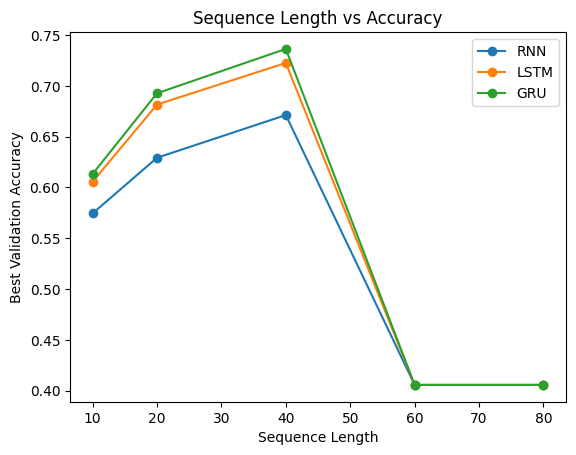

CPU times: user 127 ms, sys: 6.81 ms, total: 134 ms
Wall time: 132 ms


In [24]:
%%time

plt.plot(sequence_lengths, rnn_acc, marker='o', label='RNN')
plt.plot(sequence_lengths, lstm_acc, marker='o', label='LSTM')
plt.plot(sequence_lengths, gru_acc, marker='o', label='GRU')

plt.xlabel("Sequence Length")
plt.ylabel("Best Validation Accuracy")
plt.title("Sequence Length vs Accuracy")

plt.legend()
plt.show()